In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import os

os.chdir("../")
from scripts import utils, alerceanomalies
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.svm import OneClassSVM
import distclassipy as dcpy
from distclassipy.anomaly import DistanceAnomaly
from sklearn.model_selection import train_test_split

from sklearn.base import BaseEstimator, OutlierMixin
epsilon = np.finfo(np.float32).eps
with open("settings.txt") as f:
    settings_dict = json.load(f)
seed_val = settings_dict["seed_choice"]
np.random.seed(seed_val)
sns_dict = settings_dict["sns_dict"]
sns.set_theme(**sns_dict)

from IPython.core.display import HTML
from IPython.display import display

import squarify
set3colors = [matplotlib.colors.rgb2hex(x) for x in plt.cm.Set3.colors]
knowncolors = set3colors[:4]
unknowncolors = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9']
unknowncolors = set3colors[4:]+unknowncolors

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
def run_anom_exp(new_knowns, new_unknowns,features_to_use,std_scale, rebalance_knowns):
    subclasses = np.concatenate([new_knowns, new_unknowns])
    top_level_df = commondat[commondat['class'].isin(subclasses)]
    top_level_df = top_level_df.loc[:,list(features_to_use)+["class"]].dropna(subset=features_to_use)
    top_level_df = top_level_df[~top_level_df.index.duplicated(keep='first')]
    
    inlier_df = top_level_df[top_level_df["class"].isin(myknowns)]
    
    if rebalance_knowns:
        smallest_class_count = inlier_df["class"].value_counts().min()
        keep_indices = inlier_df.groupby("class").sample(smallest_class_count).index
        inlier_df=inlier_df[inlier_df.index.isin(keep_indices)]
        thrown_inlier_df = inlier_df[~inlier_df.index.isin(keep_indices)]
    
    outlier_df = top_level_df[top_level_df["class"].isin(myunknowns)]

    if len(outlier_df) == 0:
        return f"ERROR!!! Skipping {anomaly_subclass}, no samples found."

    # First split inliers into train/test
    inlier_train_df, inlier_test_df = train_test_split(
        inlier_df, test_size=0.2, random_state=seed_val,
        stratify=inlier_df['class'],
    )
    
    X_train_df = inlier_train_df[features_to_use]
    X_train = X_train_df.to_numpy()
    y_train_df = inlier_train_df['class']
    y_train = y_train_df.to_numpy()

    if rebalance_knowns:
        inlier_test_df = pd.concat([inlier_test_df,thrown_inlier_df])

    # Add outliers to test only
    X_test_inliers_df = inlier_test_df[features_to_use]
    X_test_outliers_df = outlier_df[features_to_use]
    X_test_df = pd.concat([X_test_inliers_df, X_test_outliers_df])
    X_test = X_test_df.to_numpy()

    y_test_df = top_level_df.loc[X_test_df.index,"class"]
    y_test = y_test_df.to_numpy()

    results_df = pd.DataFrame(index=X_test_df.index)
    results_df['class'] = y_test_df
    mask = results_df['class'].isin(new_knowns)
    results_df['status'] = np.where(mask, 'normal', 'anomalous')
    
    # # STD SCALER
    if std_scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    for model_name, model in tqdm(models_to_test.items(), desc=f"Models", leave=False):
        if "DistClassiPy" in model_name or "ClassSVDD" or "DeepSVDD" in model_name:
            model.fit(X_train, y_train)
        else:
            model.fit(X_train)
        scores = model.decision_function(X_test)
        if model_name in ["IsolationForest", "LocalOutlierFactor", "OneClassSVM"]:
            scores = -scores # Lower is more anomalous for these, so we flip

        results_df[f'score_{model_name}'] = scores

    return results_df

In [3]:
def analysis(results_df):

    # --- 1. Plot for purity v/s budget ---
    max_anom = results_df["status"].value_counts()["anomalous"]
    top_n = min(200, max_anom)
        
    methods_percent = {}
    top_ns = np.arange(start=1, stop=top_n+1)
    
    for model_name in tqdm(models_to_test.keys(),desc="method",leave=False):
        methods_percent[model_name] = []
        topresults_df = results_df.sort_values(by=f"score_{model_name}",ascending=False).iloc[:top_n]
        for i in tqdm(range(len(topresults_df)), leave=False):
            top_candidates = topresults_df.head(i)
            valcounts = top_candidates['status'].value_counts(normalize=True,ascending=True)
            if "anomalous" in valcounts.index:
                frac = valcounts["anomalous"]
                # frac = valcounts["anomalous"] / len(y_anom_df)
            else:
                frac = 0
            methods_percent[model_name].append(frac)
        plt.plot(top_ns, methods_percent[model_name][:top_n], label=model_name, linewidth=2)
    plt.ylabel("Purity", fontsize=16)
    plt.xlabel("Follow-up Budget (No. of sources)", fontsize=16)
    plt.gca().tick_params(axis='both', which='major', labelsize=16)
    plt.gca().tick_params(axis='both', which='minor', labelsize=12)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
    # plt.savefig(f"top{endnum}budget4methods.png",dpi=300,bbox_inches="tight")
    return plt.gca()

In [4]:
# Create a dictionary of all models to test
models_to_test = {
    "DistClassiPy (min-median)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='median',
        normalize_scores=True
    ),
    
    "DistClassiPy (min-mean)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='mean',
        normalize_scores=True
    ),

    "IsolationForest": IsolationForest( #using alerce anomaly params
        n_estimators=100,
        max_samples=256,
        contamination=0.001,
        random_state=seed_val+2
    ),
    "LocalOutlierFactor": LocalOutlierFactor(
        n_neighbors=20, 
        novelty=True,  # IMPORTANT: Allows use on new data
        contamination='auto'
    ),
    
    "OneClassSVM": OneClassSVM(
        kernel='rbf',
        nu=0.001
    ),

    "Autoencoder": alerceanomalies.AutoencoderAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=200,
        patience=10,
    ),


    "Variational Autoencoder": alerceanomalies.VAEAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=200,
        patience=10,
        loss_samples=5 # Number of samples for the reconstruction term in ELBO
    ),

    # "DeepSVDD": alerceanomalies.DeepSVDDAnomalyDetector(
    #     encoding_dim=32, # Can be tuned
    #     epochs=200,
    #     patience=10,
    # ),

    # "ClassSVDD": alerceanomalies.ClassSVDDAnomalyDetector(
    #     z_dim=64,
    #     epochs=250,
    #     patience=15,
    #     lr=1e-4,
    #     verbose=False
    # )
}

In [5]:
knowns = pd.read_parquet("data/allfeatures.parquet")
knowns = knowns.sample(frac=1) #shuffle

unknowns = pd.read_parquet("data/otherclassobjs_features_23AUG.parquet")
unknowns.index.name = "snid"

unknowns_lc_df = pd.read_parquet("data/otherclassobjs_23AUG.parquet")
unknowns_lc_df.index.name = "snid"
unknowns["class"] = unknowns_lc_df["class"]
assert (unknowns.index == unknowns_lc_df.index).all()

# unknowns_lc_df=unknowns_lc_df[~unknowns_lc_df["class"].isin(['d-Sct', 'Cepheid', 'EB', 'RRL'])]
# unknowns=unknowns.loc[unknowns_lc_df.index]

# unknowns_lc_df = unknowns_lc_df.loc[unknowns.index]

# assert (unknowns.index == unknowns_lc_df.index).all()

commondat = pd.concat([knowns,unknowns])

commondat=commondat.loc[(commondat[[x for x in commondat.columns if "SPM" in x]].dropna()).index]
print(commondat.shape)

del(knowns,unknowns, unknowns_lc_df)

(127263, 420)


## Case 1

In [10]:
myknowns = [
    "SNIax",
    "SNIa-91bg",
    "SNIa-SALT3",
    "SNIc-Templates",
    "SNIc+HostXT_V19",
    "SNIcBL+HostXT_V19",
    "SNIb-Templates",
    "SNIb+HostXT_V19",
    "SNIIb+HostXT_V19",
    "SNIIn+HostXT_V19"
    "SNIIn-MOSFIT",
    "SNII+HostXT_V19"
]

myunknowns = ["PISN-STELLA_HYDROGENIC",
"SLSN-I_no_host",
"SLSN-I+host",
"ILOT",
"CART",
"uLens-Single_PyLIMA",
"uLens-Single-GenLens",
"KN_B19",
"KN_K17",
"SL-SN1a",
"SL-SNII",
"SL-SNIc",
"SL-SNIb",
"PISN-MOSFIT",
"PISN-STELLA_HECORE"]


features_df=commondat[commondat["class"].isin(myknowns)]
class_df=features_df.loc[:,"class"]
features_df=features_df.drop("class", axis=1)
features_df=features_df.drop(
    ["Timespan", "Coordinate_x", "Coordinate_y", "Coordinate_z"],
    axis=1,
)

assert (features_df.index == class_df.index).all()

smallfeatures, class_df = utils.remove_correlated_features(features_df,class_df, corr_thresh = 0.8, rebalance=False)

# for c in smallfeatures.columns:
#     print(c)
myfeatures = utils.get_lcdc_features(smallfeatures, class_df, dcpy._UNIQUE_METRICS, k_features=10)
print(myfeatures)

# myfeatures = [
#     'SPM_A_g', 'SPM_beta_Y', 'SPM_chi_u', 
#     'SPM_gamma_z', 'SPM_tau_fall_i', 'SPM_tau_fall_r', 
#     'SPM_tau_fall_z', 'SPM_tau_rise_r', 'n_forced_phot_band_after_Y'
# ]

Calculating correlations...
Done!


SFS:   0%|          | 0/16 [00:00<?, ?it/s]

/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distance

EFS:   0%|          | 0/1 [00:00<?, ?it/s]

['Harmonics_mag_2_r', 'Harmonics_mag_7_i', 'SPM_A_g', 'SPM_A_z', 'SPM_gamma_i', 'SPM_tau_fall_i', 'SPM_tau_fall_r', 'SPM_tau_fall_z', 'SPM_tau_rise_u']


Models:   0%|          | 0/7 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

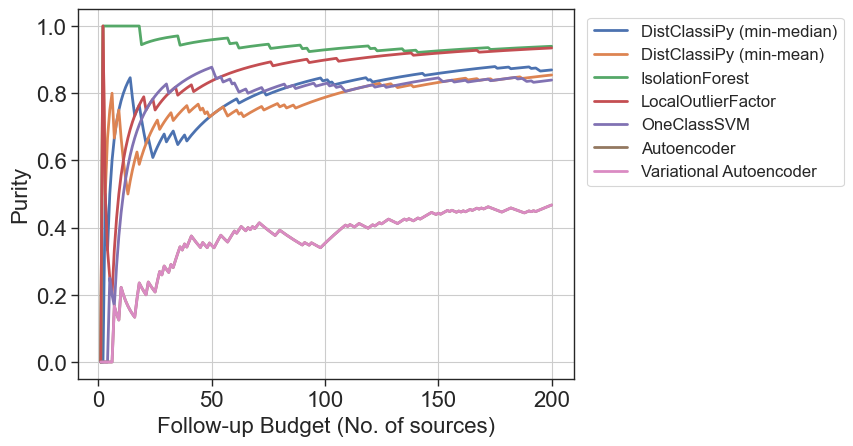

In [11]:
results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

## Case 2

In [12]:
myknowns = ['EB', 'DSCT', 'RRL', 'CEP']
myunknowns = ['PISN-STELLA_HYDROGENIC', 'PISN-MOSFIT', 'uLens-Single_PyLIMA',
        'TDE', 'SNIcBL+HostXT_V19', 'KN_B19', 'uLens-Binary', 'SL-SNII',
        'SNIc-Templates', 'SLSN-I+host', 'SNIa-SALT3', 'SNIb-Templates',
        'SNII+HostXT_V19', 'SNIa-91bg', 'SL-SNIb', 'Mdwarf-flare', 'ILOT',
        'KN_K17', 'CART', 'SNIIb+HostXT_V19', 'SNIb+HostXT_V19', 'SL-SN1a',
        'SNII-NMF', 'SNIIn+HostXT_V19', 'SNII-Templates',
        'SNIc+HostXT_V19', 'SNIax', 'SNIIn-MOSFIT', 'uLens-Single-GenLens',
        'PISN-STELLA_HECORE', 'AGN', 'SLSN-I_no_host', 'SL-SNIc',
        'dwarf-nova']


features_df=commondat[commondat["class"].isin(myknowns)]
class_df=features_df.loc[:,"class"]
features_df=features_df.drop("class", axis=1)
features_df=features_df.drop(
    ["Timespan", "Coordinate_x", "Coordinate_y", "Coordinate_z"],
    axis=1,
)

assert (features_df.index == class_df.index).all()

smallfeatures, class_df = utils.remove_correlated_features(features_df,class_df, corr_thresh = 0.8, rebalance=False)

# for c in smallfeatures.columns:
#     print(c)
myfeatures = utils.get_lcdc_features(smallfeatures, class_df, dcpy._UNIQUE_METRICS, k_features=10)
print(myfeatures)

# myfeatures = [
#     'SPM_A_g', 'SPM_beta_Y', 'SPM_chi_u', 
#     'SPM_gamma_z', 'SPM_tau_fall_i', 'SPM_tau_fall_r', 
#     'SPM_tau_fall_z', 'SPM_tau_rise_r', 'n_forced_phot_band_after_Y'
# ]

Calculating correlations...
Done!


SFS:   0%|          | 0/16 [00:00<?, ?it/s]

/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:418: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (uv / (np.dot(u, u) + np.dot(v, v) - uv))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:418: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (uv / (np.dot(u, u) + np.dot(v, v) - uv))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:418: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (uv / (np.dot(u, u) + np.dot(v, v) - uv))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:418: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (uv / (np.dot(u, u) + np.dot(v, v) - uv))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:418: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (uv / (np.dot(u, u) + np.dot(v, v) - uv))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:525: RuntimeWar

EFS:   0%|          | 0/1 [00:00<?, ?it/s]

['Harmonics_mag_4_z', 'Harmonics_phase_2_r', 'Harmonics_phase_4_i', 'Harmonics_phase_4_r', 'Multiband_period', 'Power_rate_4', 'SPM_A_r']


Models:   0%|          | 0/7 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

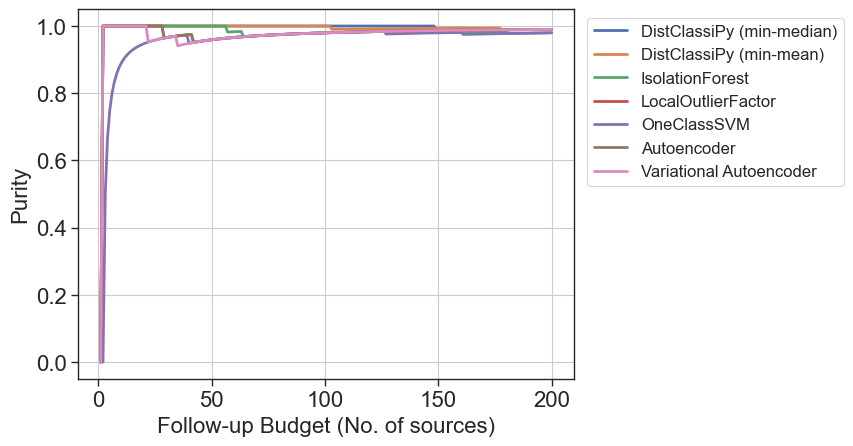

In [13]:
results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

# Case 3

In [15]:
myknowns = [
"SNIax",
"SNIa-91bg",
"SNIa-SALT3",
"SNIc-Templates",
"SNIc+HostXT_V19",
"SNIcBL+HostXT_V19",
"SNIb-Templates",
"SNIb+HostXT_V19",
"SNIIb+HostXT_V19",
"SNIIn+HostXT_V19"
"SNIIn-MOSFIT",
"SNII+HostXT_V19",
]

myunknowns = [
"KN_B19",
"KN_K17",
]


features_df=commondat[commondat["class"].isin(myknowns)]
class_df=features_df.loc[:,"class"]
features_df=features_df.drop("class", axis=1)
features_df=features_df.drop(
    ["Timespan", "Coordinate_x", "Coordinate_y", "Coordinate_z"],
    axis=1,
)

assert (features_df.index == class_df.index).all()

smallfeatures, class_df = utils.remove_correlated_features(features_df,class_df, corr_thresh = 0.8, rebalance=False)

# for c in smallfeatures.columns:
#     print(c)
myfeatures = utils.get_lcdc_features(smallfeatures, class_df, dcpy._UNIQUE_METRICS, k_features=10)
print(myfeatures)

# myfeatures = [
#     'SPM_A_g', 'SPM_beta_Y', 'SPM_chi_u', 
#     'SPM_gamma_z', 'SPM_tau_fall_i', 'SPM_tau_fall_r', 
#     'SPM_tau_fall_z', 'SPM_tau_rise_r', 'n_forced_phot_band_after_Y'
# ]

Calculating correlations...
Done!


SFS:   0%|          | 0/16 [00:00<?, ?it/s]

/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distance

EFS:   0%|          | 0/1 [00:00<?, ?it/s]

['Harmonics_mag_2_r', 'Harmonics_mag_7_i', 'SPM_A_g', 'SPM_A_z', 'SPM_gamma_i', 'SPM_tau_fall_i', 'SPM_tau_fall_r', 'SPM_tau_fall_z', 'SPM_tau_rise_u']


Models:   0%|          | 0/7 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

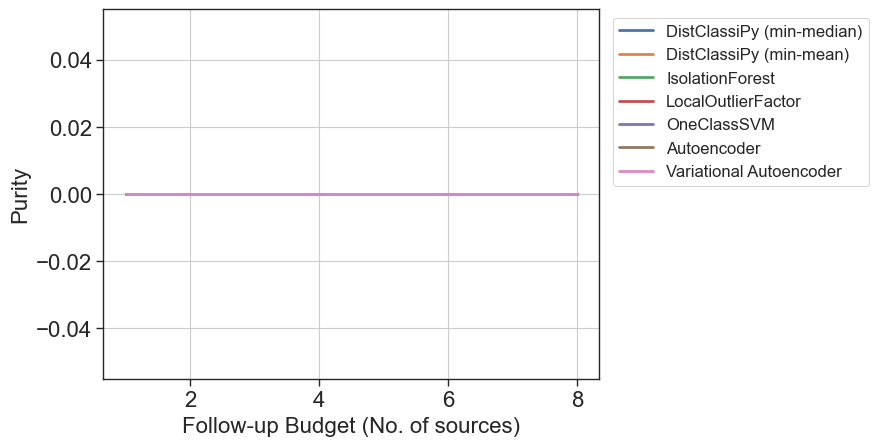

In [16]:
results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

## Case n

In [17]:
alerce_taxonomy = {
    "Transient": ["SLSN", "SNII", "SNIa", "SNIbc"],
    "Stochastic": ["QSO", "YSO", "AGN", "Blazar", "CV/Nova"],
    "Periodic": ["CEP",  "DSCT", "E", "RRL", "LPV"],
    "All": [
        "SLSN", "SNII", "SNIa", "SNIbc", 
        "QSO", "YSO", "AGN", "Blazar", "CV/Nova",
        "CEP",  "DSCT", "E", "RRL", "LPV"
    ]
}

for top_level_class, subclasses in alerce_taxonomy.items():
    print("*"*20, top_level_class, "*"*20)
    for anomaly_subclass in subclasses:
        myunknowns = [anomaly_subclass]
        myknowns = [cl for cl in subclasses if cl!=anomaly_subclass]
        print(f"Knowns: {myknowns}")
        print(f"Unknowns: {myunknowns}")

        features_df=commondat[commondat["class"].isin(myknowns)]
        class_df=features_df.loc[:,"class"]
        features_df=features_df.drop("class", axis=1)
        for x in ["Timespan", "Coordinate_x", "Coordinate_y", "Coordinate_z"]:
            if x in features_df.columns:
                features_df=features_df.drop(x, axis=1)
        
        smallfeatures, class_df = utils.remove_correlated_features(features_df,class_df, corr_thresh = 0.8, rebalance=False)
        
        try:
            myfeatures = utils.get_lcdc_features(smallfeatures, class_df, dcpy._UNIQUE_METRICS, k_features=10)
        except Exception as e:
            print(f"EXCEPTION {e}")
            myfeatures = [
                'SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g',
                'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r',
                'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r'
            ]

        if len(myfeatures)==0:
            print("ZERO FEATURES!!! DEFAULTING TO SPM")
            myfeatures = ['SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g',
                          'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r',
                          'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r']
        print(myfeatures)
        
        results_df = run_anom_exp(
            new_knowns=myknowns, 
            new_unknowns=myunknowns,
            features_to_use=myfeatures,
            std_scale=False,
            rebalance_knowns=True,
        )
        if type(results_df) is str:
            print(results_df)
            continue
        
        analysis(results_df)

******************** Transient ********************
Knowns: ['SNII', 'SNIa', 'SNIbc']
Unknowns: ['SLSN']
Calculating correlations...
Done!


SFS:   0%|          | 0/16 [00:00<?, ?it/s]

EXCEPTION Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
['SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g', 'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r', 'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r']
ERROR!!! Skipping SLSN, no samples found.
Knowns: ['SLSN', 'SNIa', 'SNIbc']
Unknowns: ['SNII']
Calculating correlations...
Done!


SFS:   0%|          | 0/16 [00:00<?, ?it/s]

EXCEPTION Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
['SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g', 'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r', 'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r']
ERROR!!! Skipping SNII, no samples found.
Knowns: ['SLSN', 'SNII', 'SNIbc']
Unknowns: ['SNIa']
Calculating correlations...
Done!


...

EFS:   0%|          | 0/1 [00:00<?, ?it/s]

['Harmonics_mag_7_i']
ERROR!!! Skipping YSO, no samples found.
Knowns: ['QSO', 'YSO', 'Blazar', 'CV/Nova']
Unknowns: ['AGN']
Calculating correlations...
Done!


SFS:   0%|          | 0/16 [00:00<?, ?it/s]

EXCEPTION Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
['SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g', 'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r', 'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r']


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

### sid thoughts:
- find best features for a problem through classification in a function
- run concrete transient anomaly examples
- try feature selection through best classification features on known classes
- try real ztf data